<img src="LOGO ITQ (2).png" width="200">

## **Examen Práctico - Tercer Parcial**
### **Nombre:** Mónica Guano
#### **Fecha:** 14/06/2026

#### 0) Cargar una de las imágenes histológicas

In [ ]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

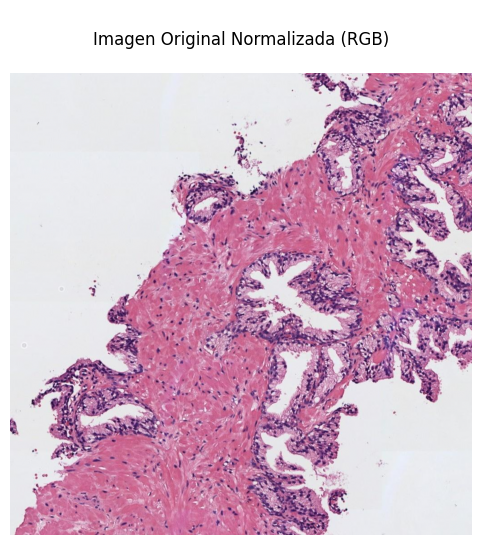

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io

#Leemos la imagen
img = io.imread('examen/histo_1.jpg')
rgb = img.copy()

#Normalizamos la imagen (normalizamos los datos dividiendo para 255)
rgb_p = rgb.astype('uint8')/255  

#Visualizar la imagen
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(rgb_p)   #(img_normalized))
plt.title("\nImagen Original Normalizada (RGB)\n")
plt.axis('off')     #Opcional: oculta los ejes para una mejor visualización
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [ ]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

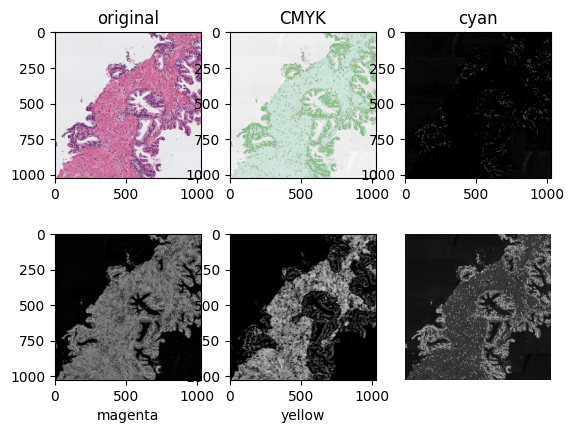

In [34]:
with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    # Extrae los canales de acuerdo con la ecuación del power point
    C = (1 - rgb_p[:,:,0] - K) / (1 - K)
    M = (1 - rgb_p[:,:,1] - K) / (1 - K)
    Y = (1 - rgb_p[:,:,2] - K) / (1 - K)

CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')  #creamos la f CMYK; transformar a una unidad de 8bytes; trannsformar a pixeles normales
C,M,Y,K = cv2.split(CMYK)  #f split

fig, ax = plt.subplots(2,3)
ax[0,0].imshow(img, cmap='gray'), ax[0,0].set_title('original')
ax[0,1].imshow(CMYK.astype('uint8'), cmap='gray'), ax[0,1].set_title('CMYK')
ax[0,2].imshow(C.astype('uint8'), cmap='gray'), ax[0,2].set_title('cyan')
ax[1,0].imshow(M.astype('uint8'), cmap='gray'), ax[1,0].set_xlabel('magenta')
ax[1,1].imshow(Y.astype('uint8'), cmap='gray'), ax[1,1].set_xlabel('yellow')
ax[1,2].imshow(K.astype('uint8'), cmap='gray'), ax[1,2].set_xlabel('black')
plt.show()


#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [ ]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

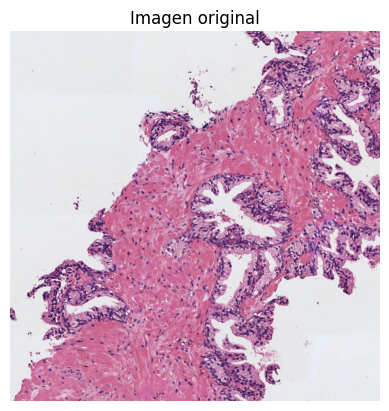

In [12]:
# SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES
img = cv2.imread('examen/histo_1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off') 
plt.show()


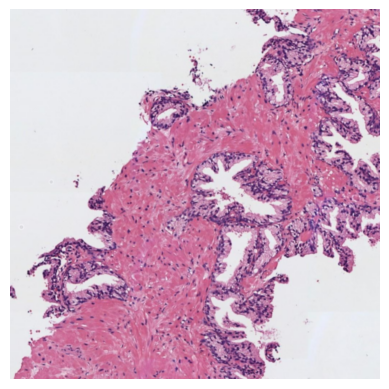

In [13]:

img_gaus = cv2.GaussianBlur(img_rgb, (5,5), 0) # (5x5) es el tamaño del filtro y 0 es la desviación estándar
plt.imshow(img_gaus, cmap='gray')
plt.axis('off') 
plt.show()

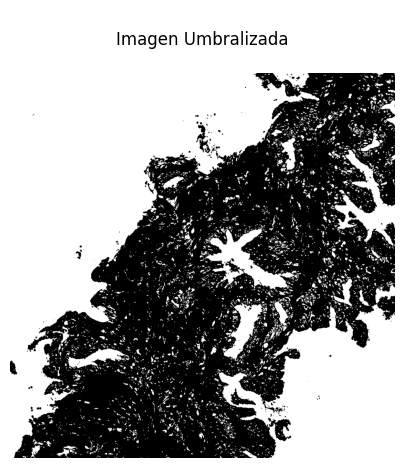

In [14]:

#La UMBRALIZCIÓN (THRESHOLDING): técnica de segmentación de imágenes para el procesamiento digital de imágenes y visión por computadora.
#Su objetivo principal: convertir una imagen en escala de grises (o a color) en una imagen binaria (blanco y negro puramente).

import matplotlib.pyplot as plt
import cv2
import numpy as np


img = cv2.imread('examen/histo_1.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(img_gray,0,1,cv2.THRESH_OTSU)

plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='gray')
plt.title("\nImagen Umbralizada\n")
plt.axis('off') 
plt.show()



#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [42]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

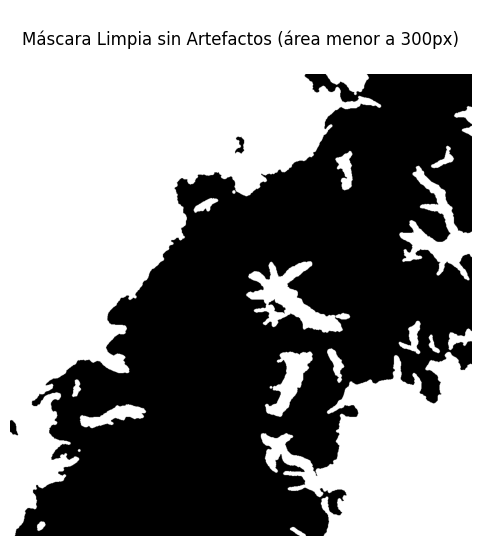

In [65]:
from skimage import morphology                       #skimage: librería principal (paquete completo de procesamiento de imágenes)
                                                     #morphology: analizar, procesar y contrastar las formas y estructuras geométricas
from skimage.morphology import remove_small_objects  

mask_clean = morphology.remove_small_objects(mask_lumen_inicial, max_size=300)  #la función elimina objetos pequeños
mask_clean = morphology.remove_small_holes(mask_clean, max_size=300)            #la función elimina agujeros pequeños
selem = morphology.disk(3)
mask_clean = morphology.opening(mask_clean, selem)
plt.figure(figsize=(6, 6))
plt.imshow(mask_clean, cmap='gray')
plt.title("\nMáscara Limpia sin Artefactos (área menor a 300px)\n")
plt.axis('off')
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [76]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

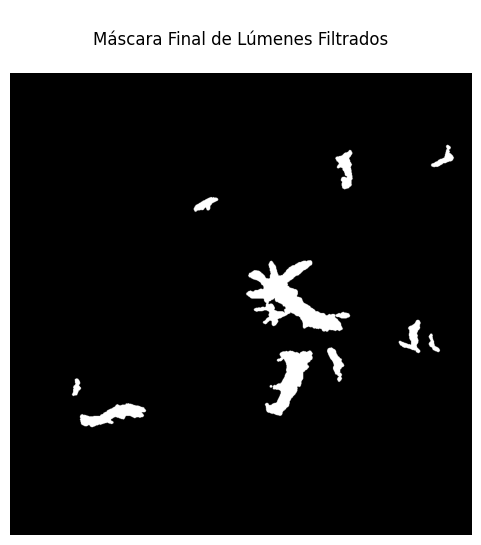

In [75]:
label_image = measure.label(mask_clean, connectivity=2)
props = measure.regionprops(label_image)

# Filtramos lúmenes eliminando aquellos que tocan los bordes de la imagen 
# y los que son excesivamente pequeños para el análisis clínico
mask_lumen_final = np.zeros_like(mask_clean, dtype=bool)
valid_props = []

for prop in props:
    # Evitar elementos que tocan los bordes
    ymin, xmin, ymax, xmax = prop.bbox
    if ymin == 0 or xmin == 0 or ymax == mask_clean.shape[0] or xmax == mask_clean.shape[1]:
        continue
    # Filtrado por tamaño mínimo significativo (ej. 500 píxeles)
    if prop.area > 300:
        mask_lumen_final[label_image == prop.label] = True
        valid_props.append(prop)

plt.figure(figsize=(6, 6))
plt.imshow(mask_lumen_final, cmap='gray')
plt.title("\nMáscara Final de Lúmenes Filtrados\n")
plt.axis('off')
plt.show()

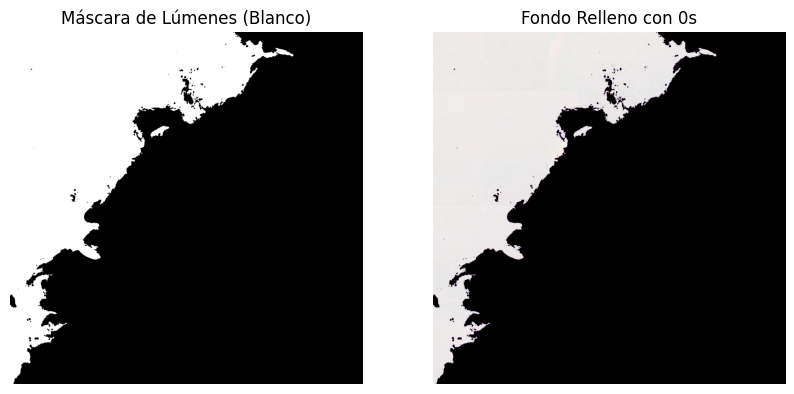

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import color  # 1. IMPORTANTE: Necesitamos este módulo
from skimage.segmentation import flood_fill

# === CORRECCIÓN AQUÍ ===
# Convertimos tu imagen original 'img' a escala de grises
imagen_gris = color.rgb2gray(img)
# =======================

# Pon aquí las coordenadas (y, x) aproximadas de tus dos lúmenes
semilla1 = (150, 200)
semilla2 = (300, 420)

# El resto del código se queda exactamente igual...
mascara_lumenes = np.zeros_like(imagen_gris, dtype=bool)

reg_1 = flood_fill(imagen_gris, semilla1, new_value=1, tolerance=0.15)
mascara_lumenes = mascara_lumenes | (reg_1 == 1)

reg_2 = flood_fill(imagen_gris, semilla2, new_value=1, tolerance=0.15)
mascara_lumenes = mascara_lumenes | (reg_2 == 1)

imagen_solo_lumenes = img.copy()
imagen_solo_lumenes[~mascara_lumenes] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(mascara_lumenes, cmap="gray")
ax[0].set_title("Máscara de Lúmenes (Blanco)")
ax[0].axis("off")

ax[1].imshow(imagen_solo_lumenes)
ax[1].set_title("Fondo Relleno con 0s")
ax[1].axis("off")

plt.show()

In [1]:
from skimage.segmentation import flood, flood_fill

# --- AUTOMATIZACIÓN DE SEMILLAS ---
# Sabemos que las esquinas de la imagen pertenecen inequívocamente al "Fondo/Background".
# Usamos flood_fill desde las esquinas superiores para aislar y apagar el fondo.

mask_lumen_only = mask_clean.copy()

# Semilla 1: Esquina superior izquierda (0,0)
if mask_lumen_only[0, 0] == 1:
    mask_lumen_only = flood_fill(mask_lumen_only, (0, 0), 0)

# Semilla 2: Esquina superior derecha (0, ancho-1) para asegurar si hay divisiones
h, w = mask_lumen_only.shape
if mask_lumen_only[0, w - 1] == 1:
    mask_lumen_only = flood_fill(mask_lumen_only, (0, w - 1), 0)

# Visualizar la máscara resultante (Solo lúmenes internos en blanco)
plt.figure(figsize=(6, 6))
plt.imshow(mask_lumen_only, cmap='gray')
plt.title("Máscara con Fondo Eliminado (Solo Lúmenes)")
plt.axis('off')
plt.show()

NameError: name 'mask_clean' is not defined

#### 5) Rellenar los objetos de los lúmenes

In [ ]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

In [5]:
from scipy.ndimage import binary_fill_holes

# Rellenar los huecos internos de las estructuras de los lúmenes
mask_filled = binary_fill_holes(mask_lumen_only).astype(np.uint8)

# Visualizar la máscara resultante
plt.figure(figsize=(6, 6))
plt.imshow(mask_filled, cmap='gray')
plt.title("Lúmenes con Huecos Rellenados")
plt.axis('off')
plt.show()

NameError: name 'mask_lumen_only' is not defined

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [ ]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

In [8]:
# Detección de bordes de Canny
import cv2

canny = cv2.Canny(img_gaus, 255/3, 255) # minValue and maxValue. Canny recomienda que minValue sea 3 veces menor que maxValue
kernel = np.ones((2,2), 'uint8')
#canny = cv2.dilate(canny, kernel, iterations=2)
#canny = cv2.erode(canny, kernel, iterations=2)
print(kernel)

plt.imshow(canny, cmap='gray')
plt.show()

NameError: name 'img_gaus' is not defined

#### 7) Identificar y cropear el lumen más grande

In [ ]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [ ]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad